In [ ]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import setup_plotting, switch_cwd_to_root

switch_cwd_to_root()

figure_dir = "figures/supp-figures"
setup_plotting(figure_dir, display_dpi=300, save_dpi=300)

import scanpy as sc

from spatial_tcr.gene_colocalization import *
from spatial_tcr.tcr import get_tcr_genes

## Load data

In [ ]:
data_dir = "data/xenium/processed"
path = f"{data_dir}/08.2-kidney_tcr_clonal_clusters_peri_glom_annot.h5ad"
adata = sc.read_h5ad(path)

# remove control samples
adata = adata[adata.obs["condition"] == "ANCA"].copy()

sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata

AnnData object with n_obs × n_vars = 389390 × 436
    obs: 'sample', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'n_counts', 'condition', 'cc', 'cell_type_no_tcr', 'cell_type_no_tcr_prob', 'tcell_subtype', 'cell_type_l1', 'cell_type_l2', 'is_ATL', 'is_B', 'is_CNT', 'is_DCT', 'is_DTL', 'is_EC', 'is_FIB', 'is_IC', 'is_MAST', 'is_MC', 'is_MDC', 'is_Mac', 'is_N', 'is_NEU', 'is_PC', 'is_PEC', 'is_PL', 'is_POD', 'is_PT', 'is_PapE', 'is_T', 'is_TAL', 'is_VSM/P', 'is_cDC', 'is_cycMNP', 'is_glom. EC', 'is_pDC', 'is_unknown', 'leiden', 'glom_annot', 'in_glom', 'tcell_density_group', 'tcell_density', 'tcell_infiltrate', 'cell_type_l1.1', 'av_

In [3]:
av_genes, bv_genes, dv_genes, gv_genes, tv_genes = get_tcr_genes(adata)

Found 35 TRAV genes, 36 TRBV genes, 3 TRDV genes, 14 TRGV genes


In [4]:
ac_genes = [g for g in adata.var_names if g.startswith("TRAC")]
bc_genes = [g for g in adata.var_names if g.startswith("TRBC")]
bc_genes, ac_genes

(['TRBC1', 'TRBC2'], ['TRAC'])

In [5]:
cd3_genes = [g for g in adata.var_names if g.startswith("CD3")]
cd3_genes

['CD3D', 'CD3E', 'CD3G']

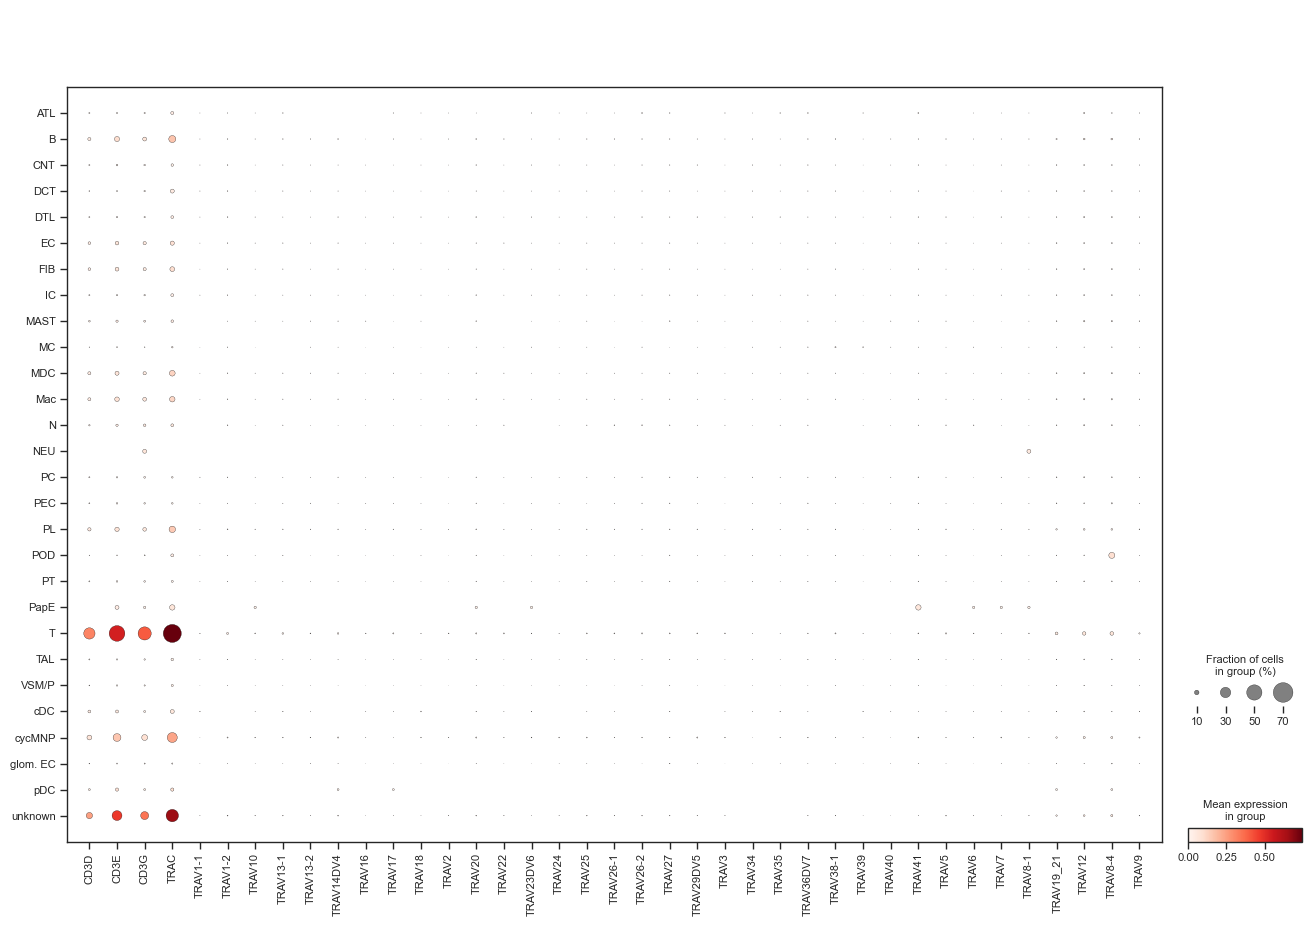

In [6]:
sc.pl.dotplot(adata, var_names=cd3_genes + ac_genes + av_genes, groupby="cell_type_l1")

In [7]:
# calculate TRAV and TRBV expression
adata.obs["TRAV_detected"] = (adata[:, av_genes].X.toarray().sum(axis=1) > 0).astype(
    int
)
adata.obs["TRBV_detected"] = (adata[:, bv_genes].X.toarray().sum(axis=1) > 0).astype(
    int
)

# correlate TRAV and TRBV with CD3X gene expression via

In [8]:
# correlate TRAV and TRBV with CD3X gene expression via

/bonn-epyc/projects/dschaub/analysis-projects/xenium-tcr/src/spatial_tcr/gene_colocalization.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ct, idx in adata.obs.groupby(group_key).indices.items():


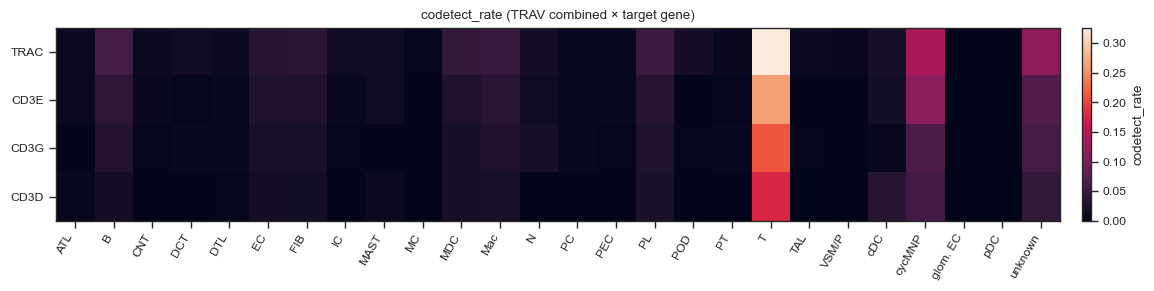

In [9]:
targets = sorted(set(cd3_genes + ac_genes))

# 1) combined TRAV detection
add_combined_detection(adata, av_genes, obs_key="TRAV_detected", thresh=0.0)

# 2) per-cell-type codetection with each target gene
df = codetection_by_group(
    adata,
    group_key="cell_type_l1",
    combined_key="TRAV_detected",
    target_genes=targets,
    thresh=0.0,
    min_cells=25,
)

# 3) heatmap
plot_codetect_heatmap(df, group_key="cell_type_l1", value_col="codetect_rate")

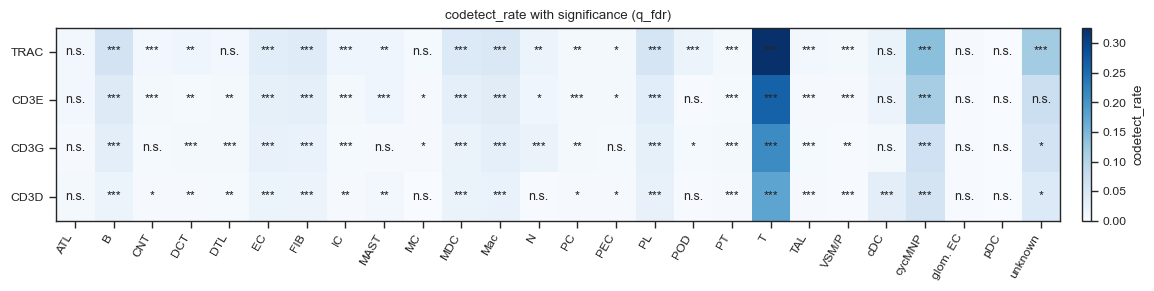

In [10]:
# df from codetection_by_group(...)
plot_codetect_heatmap_with_stars(
    df,
    group_key="cell_type_l1",
    value_col="codetect_rate",
    p_col="q_fdr",  # or "p_fisher"
    show_ns=False,
    min_cells=25,
)

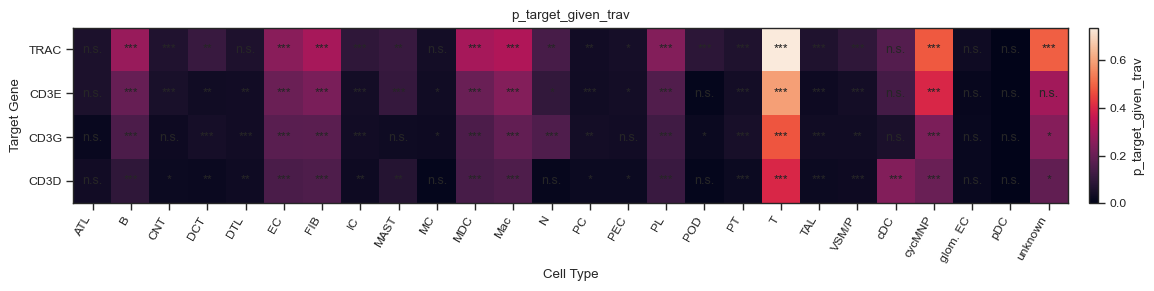

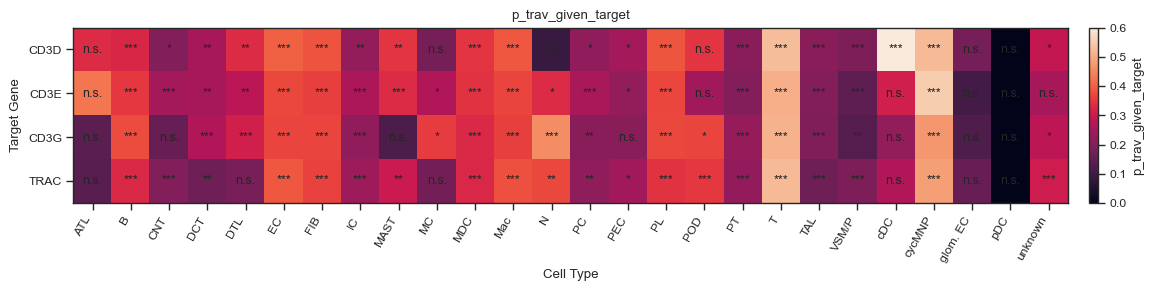

In [11]:
df2 = add_conditional_codetect_cols(df)

# Heatmap: among TRAV+ cells, how often is CD3*/TRAC* detected?
plot_heatmap_with_optional_stars(
    df2,
    group_key="cell_type_l1",
    value_col="p_target_given_trav",
    p_col="q_fdr",
    show_stars=True,
    show_ns=False,
)

# (Optional) The inverse view:
plot_heatmap_with_optional_stars(
    df2,
    group_key="cell_type_l1",
    value_col="p_trav_given_target",
    p_col="q_fdr",
    show_stars=True,
    show_ns=False,
)

/bonn-epyc/projects/dschaub/analysis-projects/xenium-tcr/src/spatial_tcr/gene_colocalization.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return np.asarray(s).ravel()


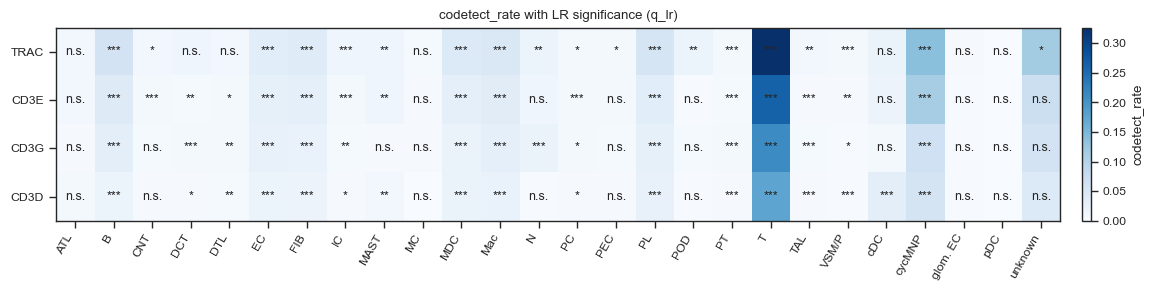

In [13]:
# Combined TRAV detection per cell
add_combined_detection(adata, av_genes, obs_key="TRAV_detected", thresh=0.0)

# Fit per cell type, per target gene
df_lr = codetect_with_logreg_pvals(
    adata,
    celltype_key="cell_type_l1",
    trav_key="TRAV_detected",
    target_genes=targets,
    depth_key=None,  # auto-detect (or set explicitly)
    min_cells=25,
)

# Heatmap: color = codetect_rate, stars = depth-adjusted LR q-values
plot_codetect_heatmap_with_lr_stars(
    df_lr,
    celltype_key="cell_type_l1",
    value_col="codetect_rate",
    p_col="q_lr",
    show_ns=False,
)